In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Driver_Behavior.csv")

print(df.head())

   speed_kmph   accel_x   accel_y  brake_pressure  steering_angle   throttle  \
0   36.075011  0.535763  0.708633       23.107812       -3.169956  53.123505   
1   38.090536  0.973764  0.044312       36.961137      -24.380082  36.383904   
2   71.314445  3.638434  0.789375       79.734087       -6.100238  78.110507   
3   86.485997  2.441366  0.039135       45.007002       17.886191  82.794935   
4   52.816777 -0.201763  0.560619       38.759612       -4.104323  61.432375   

   lane_deviation  phone_usage  headway_distance  reaction_time behavior_label  
0        0.851871            1         17.996005       1.400050     Distracted  
1        1.459495            1         29.904182       1.428537     Distracted  
2        0.254723            0         11.126012       0.406950     Aggressive  
3        0.911664            0         11.064505       0.539964     Aggressive  
4        1.591244            1         21.967570       1.369908     Distracted  


In [3]:

print(df['behavior_label'].value_counts())


behavior_label
Distracted    10000
Aggressive    10000
Safe          10000
Name: count, dtype: int64


In [4]:
X = df.drop('behavior_label', axis='columns')

y = df['behavior_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(len(X_train))
print(len(X_test))

24000
6000


In [5]:
model = RandomForestClassifier(n_estimators=20)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [6]:

sample_driver = [[
    40,
    0.5,
    0.3,
    20,
    -5,
    45,
    0.8,
    1,
    18,
    1.2
]]

prediction = model.predict(sample_driver)

print("Prediction:", prediction[0])

Prediction: Distracted


/home/rithik-ca/Documents/Learning and Projects/MLops_Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [7]:

y_predicted = model.predict(X_test)

cm = confusion_matrix(y_test, y_predicted)

print(cm)

plt.figure (figsize = [10,7])

[[2024    0    0]
 [   0 2020    0]
 [   0    0 1956]]


<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

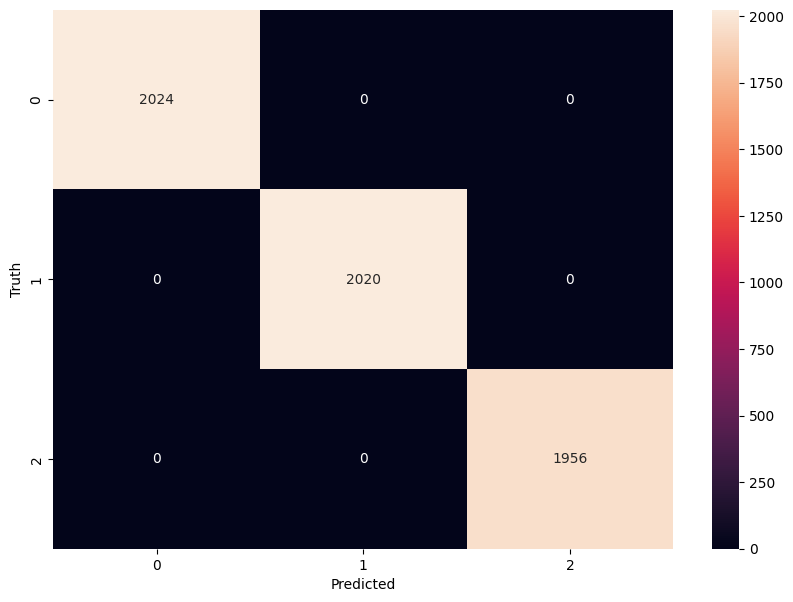

In [8]:
plt.figure(figsize=(10,7))

sn.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')

plt.show()

In [9]:
print(classification_report(y_test, y_predicted))


              precision    recall  f1-score   support

  Aggressive       1.00      1.00      1.00      2024
  Distracted       1.00      1.00      1.00      2020
        Safe       1.00      1.00      1.00      1956

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [10]:


with open("driver_behavior_random_forest.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")




Model saved successfully


In [11]:
with open("driver_behavior_random_forest.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully")

Model loaded successfully


In [12]:
loaded_prediction = loaded_model.predict(sample_driver)

print("Prediction using Loaded Model:", loaded_prediction[0])

Prediction using Loaded Model: Distracted


/home/rithik-ca/Documents/Learning and Projects/MLops_Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
